# Lambda, Map, Filter & Apply
**Topic:** Python Fundamentals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Define** a lambda function and explain when it is appropriate compared to a full `def`
- **Apply** `map()` and `filter()` to transform and select items from a sequence
- **Interpret** how `df.apply()` in pandas extends these same ideas across DataFrame rows and columns

---
## How we got here

In *06: List Comprehensions* we saw a concise syntax for building transformed lists. Lambda functions take conciseness further: they define a small, unnamed function in a single expression, right at the point of use. They are most useful when you need to pass a short function to another function, which is exactly what `map()`, `filter()`, and pandas `apply()` require.

---
## Why this matters for data science

Pandas `df["col"].apply(func)` is one of the most-used lines in data science code. It applies any function, including a lambda, to every element of a Series or every row of a DataFrame. When no built-in vectorized method exists for your transformation, `apply()` with a lambda is the readable escape hatch. Understanding the relationship between `lambda`, `map()`, and `apply()` also demystifies the functional programming style used throughout the pandas and PySpark APIs.

---
## Try it yourself

In [ ]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.
# Wrap everything around a list, or we'll get a map object
# Lambda functions: think of them as a temporary function

amounts = [12.5, 340.0, 88.75, 1200.0, 55.0, 9.99]

# lambda: anonymous function defined inline
double = lambda x: x * 2

# map: apply a function to every item
doubled = list(map(double, amounts))

# filter: keep only items where the function returns True
high_value = list(filter(lambda x: x > 100, amounts))

print('original:   ', amounts)
print('doubled:    ', doubled)
print('high value: ', high_value)

original:    [12.5, 340.0, 88.75, 1200.0, 55.0, 9.99]
doubled:     [25.0, 680.0, 177.5, 2400.0, 110.0, 19.98]
high value:  [340.0, 1200.0]


In [5]:
# ✏️ Your turn — modify this code:
# 1. Change the risk threshold from 200 to 500 and observe the tier distribution
# 2. Rewrite the bucket lambda as a regular def function — same result?
# 3. Use map() instead of apply() to apply bucket — does it work on a Series?

import pandas as pd

transactions = pd.Series([15, 320, 88, 950, 42, 710, 160, 3])

bucket = lambda x: 'high' if x >= 200 else 'low'
tiers  = transactions.apply(bucket)

print(tiers.value_counts())

low     5
high    3
Name: count, dtype: int64


In [ ]:
# 🎯 Challenge:
# Using lambda and filter(), extract all words longer than 4 characters from this list:
# words = ['data', 'science', 'is', 'fascinating', 'and', 'powerful']
# Hint: use len() inside your lambda to check the word length

words = ['data', 'science', 'is', 'fascinating', 'and', 'powerful']

# Your code here:
length = lambda x: x == len(4)

---
## What's happening?

A `lambda` is a function without a name, defined in a single expression. It can be assigned to a variable or passed directly as an argument.

| Tool | Syntax | Typical use in pandas |
|------|--------|----------------------|
| `lambda` | `lambda x: x * 2` | Inline function for `apply()` |
| `map(func, iterable)` | `map(str.upper, names)` | Transform every item in a list |
| `filter(func, iterable)` | `filter(lambda x: x > 0, vals)` | Keep only items where func is True |
| `Series.apply(func)` | `df["col"].apply(lambda x: ...)` | Element-wise transform in pandas |
| `DataFrame.apply(func, axis=1)` | `df.apply(lambda row: ..., axis=1)` | Row-wise transform across columns |

```python
# Three equivalent ways to cap a value at 100
# 1. Named function
def cap(x):
    return min(x, 100)

# 2. Lambda
cap = lambda x: min(x, 100)

# 3. Applied to a pandas column
df["score_capped"] = df["score"].apply(lambda x: min(x, 100))
# Or using the vectorized equivalent:
df["score_capped"] = df["score"].clip(upper=100)
```

### Prefer vectorized methods when they exist

`apply()` with a lambda runs a Python function on each element one at a time, which is much slower than a vectorized numpy operation. Use `apply()` for logic that has no vectorized equivalent; use `.clip()`, `.map()`, or arithmetic operators when they do.

Return to the widget and compare the element-wise and row-wise `apply()` modes to see when axis=1 is needed.

---
## A direct example: applying a rule to every row

Five salaries, one rule: earn $60,000 or more and the bonus is 10%; below that it is 5%. One lambda handles the rule and `apply()` runs it on every value.

- **Notice:** The lambda reads left to right like a sentence: if x ≥ 60,000 return 10%, otherwise 5%
- **Notice:** `apply()` passes each salary in as `x` — there is no loop to write
- **Notice:** The same logic as a `def` function would take five lines; here it takes one

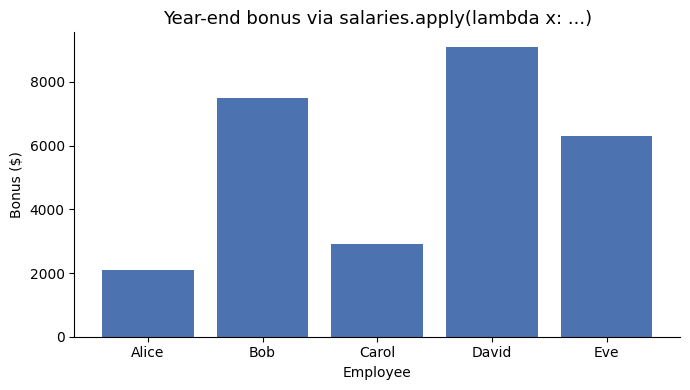

In [6]:
names    = ["Alice", "Bob", "Carol", "David", "Eve"]
salaries = pd.Series([42_000, 75_000, 58_000, 91_000, 63_000], index=names)

bonuses = salaries.apply(lambda x: x * 0.10 if x >= 60_000 else x * 0.05)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, bonuses, color="#4C72B0")
ax.set_title("Year-end bonus via salaries.apply(lambda x: ...)", fontsize=13)
ax.set_xlabel("Employee")
ax.set_ylabel("Bonus ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Real-world example: Categorizing transaction amounts in a banking dataset

A fraud detection pipeline needs to bucket raw transaction amounts into risk tiers. There is no single pandas method that applies custom business rules, so `apply()` with a lambda is the right tool.

The chart shows the distribution of transactions before and after applying the bucketing lambda across a column of 500 simulated transactions.

Notice:

- **Notice:** The lambda condenses five lines of `if`/`elif`/`else` logic into a single expression passed to `apply()`, keeping the pipeline readable without defining a named function
- **Notice:** The resulting category column has a natural ordering (low, medium, high, very_high) that maps cleanly to an ordinal encoder in the modeling step
- **Notice:** The "very high" tier is rare by design: fraud detection pipelines assign it a disproportionate share of review resources, so keeping it small matters

> **Discussion question:** After running `.apply()` with this lambda, a teammate suggests replacing it with `pd.cut()`. What would you gain and what would you lose by switching to `pd.cut()`?

In [ ]:
np.random.seed(55)

# ── Transaction risk-tier bucketing with apply + lambda ───────────────────────
n       = 500
amounts = np.abs(np.random.lognormal(mean=4.5, sigma=1.2, size=n))
df_tx   = pd.DataFrame({"amount": amounts})

bucket = lambda x: (
    "low"       if x < 50    else
    "medium"    if x < 200   else
    "high"      if x < 1000  else
    "very_high"
)
df_tx["risk_tier"] = df_tx["amount"].apply(bucket)

tier_order  = ["low", "medium", "high", "very_high"]
tier_counts = df_tx["risk_tier"].value_counts().reindex(tier_order)
tier_colors = ["#F58518", "#4C72B0", "#E45756", "#8B0000"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tier_order, tier_counts.values, color=tier_colors)
for bar, count in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(count), ha="center", va="bottom", fontsize=11)
ax.set_title("Transaction Risk Tiers — Bucketed via DataFrame.apply(lambda)", fontsize=13)
ax.set_xlabel("Risk Tier")
ax.set_ylabel("Number of Transactions")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### When to use lambda vs def vs vectorized

| Situation | Best choice | Reason |
|-----------|-------------|--------|
| Simple one-expression transform in `apply()` | `lambda` | Keeps logic inline; no need for a named function |
| Multi-line or reusable transform | `def` | Readable, testable, can have a docstring |
| Arithmetic or comparison on a whole column | Vectorized (`+`, `*`, `.clip()`) | 10–100x faster than `apply()` |
| Apply to every row using multiple columns | `df.apply(func, axis=1)` | Lambda or def, operates on each row as a Series |
| Apply to every column | `df.apply(func, axis=0)` | Compute column-level statistics or summaries |

---
## Key takeaway

> **Lambda is a one-expression anonymous function; paired with pandas `.apply()` it transforms any column or row using custom logic that no built-in method covers, at the cost of speed compared to vectorized operations.**

---
*Next up: Object-Oriented Programming — why classes exist, how they bundle data and behavior together, and how scikit-learn uses this structure for every model you will train*